<a href="https://colab.research.google.com/github/Srinivas497/MLops/blob/main/MLOPS_Hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas scikit-learn matplotlib joblib mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

DATA_PATH = "/content/Curriculum_Industry_Skill_Alignment.csv"

if not os.path.exists(DATA_PATH):
    print("Upload titanic.csv")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    if uploaded_name != "titanic.csv":
        os.rename(uploaded_name, DATA_PATH)
else:
    print("Using existing file:", DATA_PATH)

Using existing file: /content/Curriculum_Industry_Skill_Alignment.csv


In [ ]:
df = pd.read_csv(DATA_PATH)
required_columns = [
    "Student_ID", "Gender", "Semester", "CGPA", "Programming", "DSA",
    "AI_ML", "Communication", "Aptitude", "Teamwork", "Problem_Solving",
    "Internship", "Certifications", "Projects_Completed", "Placement_Status"
]
actual_present_columns = [col for col in required_columns if col in df.columns]
missing_from_expected = [col for col in required_columns if col not in df.columns]

if missing_from_expected:
    print(f"Warning: The following expected columns are missing: {missing_from_expected}. Analyzing only available columns from the expected list.")

print("Dataset shape:", df.shape)
display(df.head())

if actual_present_columns:
    print("\nMissing values:")
    print(df[actual_present_columns].isnull().sum())
else:
    print("\nNo recognized columns found to check for missing values.")

target_column = 'Placement_Status'
if target_column in df.columns:
    print(f"\nTarget distribution ('{target_column}'):")
    print(df[target_column].value_counts(dropna=False))
else:
    print(f"\n'{target_column}' column not found for target distribution. Please adjust `target_column` if another column is intended.")


Dataset shape: (100, 25)


,Student_ID,Gender,Semester,CGPA,Programming,DSA,DBMS,OS,CN,OOP,...,AI_ML,Communication,Aptitude,Teamwork,Problem_Solving,Internship,Certifications,Projects_Completed,Placement_Status,Industry_Readiness
0,S001,Female,7,8.43,3,7,6,6,5,4,...,6,6,3,6,9,Yes,3,5,Not Placed,Not Ready
1,S002,Female,7,8.88,5,9,8,7,5,6,...,8,8,7,3,10,Yes,3,1,Placed,Ready
2,S003,Male,7,8.68,3,6,7,4,6,4,...,8,8,6,7,4,Yes,4,6,Not Placed,Not Ready
3,S004,Male,8,7.76,7,6,8,3,6,3,...,8,6,10,9,10,Yes,2,2,Not Placed,Not Ready
4,S005,Male,8,8.84,9,9,8,6,5,10,...,9,4,9,9,10,No,4,1,Not Placed,Not Ready



Missing values:
Student_ID            0
Gender                0
Semester              0
CGPA                  0
Programming           0
DSA                   0
AI_ML                 0
Communication         0
Aptitude              0
Teamwork              0
Problem_Solving       0
Internship            0
Certifications        0
Projects_Completed    0
Placement_Status      0
dtype: int64

Target distribution ('Placement_Status'):
Placement_Status
Not Placed    95
Placed         5
Name: count, dtype: int64


In [ ]:
feature_columns = [
    "Gender", "Semester", "CGPA", "Programming", "DSA", "DBMS", "OS", "CN", "OOP",
    "AI_ML", "Communication", "Aptitude", "Teamwork", "Problem_Solving",
    "Internship", "Certifications", "Projects_Completed", "Industry_Readiness"
]

X = df[feature_columns].copy()
y = df["Placement_Status"].copy()

print("Features:", feature_columns)
print("Target: Placement_Status")

display(X.head())
print("\nTarget values (first 5):")
display(y.head())

Features: ['Gender', 'Semester', 'CGPA', 'Programming', 'DSA', 'DBMS', 'OS', 'CN', 'OOP', 'AI_ML', 'Communication', 'Aptitude', 'Teamwork', 'Problem_Solving', 'Internship', 'Certifications', 'Projects_Completed', 'Industry_Readiness']
Target: Placement_Status


,Gender,Semester,CGPA,Programming,DSA,DBMS,OS,CN,OOP,AI_ML,Communication,Aptitude,Teamwork,Problem_Solving,Internship,Certifications,Projects_Completed,Industry_Readiness
0,Female,7,8.43,3,7,6,6,5,4,6,6,3,6,9,Yes,3,5,Not Ready
1,Female,7,8.88,5,9,8,7,5,6,8,8,7,3,10,Yes,3,1,Ready
2,Male,7,8.68,3,6,7,4,6,4,8,8,6,7,4,Yes,4,6,Not Ready
3,Male,8,7.76,7,6,8,3,6,3,8,6,10,9,10,Yes,2,2,Not Ready
4,Male,8,8.84,9,9,8,6,5,10,9,4,9,9,10,No,4,1,Not Ready



Target values (first 5):


,Placement_Status
0,Not Placed
1,Placed
2,Not Placed
3,Not Placed
4,Not Placed


In [ ]:
# Define a random state for reproducibility
RANDOM_STATE = 42

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 80
Testing records: 20


In [ ]:
numerical_features = ['Semester', 'CGPA', 'Programming', 'DSA', 'DBMS', 'OS', 'CN', 'OOP', 'AI_ML', 'Communication', 'Aptitude', 'Teamwork', 'Problem_Solving', 'Certifications', 'Projects_Completed']
categorical_features = ['Gender', 'Internship', 'Industry_Readiness']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

print("Preprocessing and model pipeline created successfully.")


Preprocessing and model pipeline created successfully.


In [ ]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

baseline_start = time.time()
baseline_pipeline.fit(X_train, y_train)
baseline_runtime = time.time() - baseline_start

baseline_predictions = baseline_pipeline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline test accuracy:", round(baseline_accuracy, 4))
print("Baseline runtime (seconds):", round(baseline_runtime, 2))
print("\nClassification report:")
print(classification_report(y_test, baseline_predictions))

Baseline test accuracy: 1.0
Baseline runtime (seconds): 0.95

Classification report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00        19
      Placed       1.00      1.00      1.00         1

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

number_of_grid_combinations = 1
for values in param_grid.values():
    number_of_grid_combinations *= len(values)

print("Grid combinations:", number_of_grid_combinations)
print("Approximate model fits with 5-fold CV:", number_of_grid_combinations * 5)

Grid combinations: 36
Approximate model fits with 5-fold CV: 180


In [ ]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_start = time.time()
grid_search.fit(X_train, y_train)
grid_runtime = time.time() - grid_start

print("Best Grid Search parameters:")
print(grid_search.best_params_)
print("Best Grid Search CV accuracy:", round(grid_search.best_score_, 4))
print("Grid Search runtime (seconds):", round(grid_runtime, 2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Grid Search parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best Grid Search CV accuracy: 0.975
Grid Search runtime (seconds): 58.25


In [ ]:
from sklearn.metrics import make_scorer, f1_score

f1_weighted_scorer = make_scorer(f1_score, average='weighted')

grid_search_f1 = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=f1_weighted_scorer,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV re-initialized with f1_weighted scoring.")

GridSearchCV re-initialized with f1_weighted scoring.


In [ ]:
grid_f1_start = time.time()
grid_search_f1.fit(X_train, y_train)
grid_f1_runtime = time.time() - grid_f1_start

print("Best Grid Search parameters (f1_weighted):")
print(grid_search_f1.best_params_)
print("Best Grid Search CV f1_weighted score:", round(grid_search_f1.best_score_, 4))
print("Grid Search runtime (seconds) (f1_weighted):", round(grid_f1_runtime, 2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Grid Search parameters (f1_weighted):
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best Grid Search CV f1_weighted score: nan
Grid Search runtime (seconds) (f1_weighted): 51.42


In [ ]:
grid_best_model = grid_search.best_estimator_
grid_predictions = grid_best_model.predict(X_test)
grid_accuracy = accuracy_score(y_test, grid_predictions)

print("Grid Search test accuracy:", round(grid_accuracy, 4))
print("\nClassification report:")
print(classification_report(y_test, grid_predictions))

Grid Search test accuracy: 0.95

Classification report:
              precision    recall  f1-score   support

  Not Placed       1.00      0.95      0.97        19
      Placed       0.50      1.00      0.67         1

    accuracy                           0.95        20
   macro avg       0.75      0.97      0.82        20
weighted avg       0.97      0.95      0.96        20



In [ ]:
param_distributions = {
    "model__n_estimators": [50, 100, 150, 200, 300, 400],
    "model__max_depth": [None, 3, 5, 8, 10, 15],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None]
}

# Ensure f1_weighted_scorer is defined from previous steps
from sklearn.metrics import make_scorer, f1_score
f1_weighted_scorer = make_scorer(f1_score, average='weighted')

random_search_f1 = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=4, # Changed cv from 5 to 4 to handle minority class with 4 samples
    scoring=f1_weighted_scorer, # Changed to f1_weighted_scorer
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_f1_start = time.time()
random_search_f1.fit(X_train, y_train)
random_f1_runtime = time.time() - random_f1_start

print("Best Random Search parameters (f1_weighted):")
print(random_search_f1.best_params_)
print("Best Random Search CV f1_weighted score:", round(random_search_f1.best_score_, 4))
print("Random Search runtime (seconds) (f1_weighted):", round(random_f1_runtime, 2))

Fitting 4 folds for each of 30 candidates, totalling 120 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Random Search parameters (f1_weighted):
{'model__n_estimators': 200, 'model__min_samples_split': 4, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 15}
Best Random Search CV f1_weighted score: nan
Random Search runtime (seconds) (f1_weighted): 48.1


In [ ]:
random_best_model = random_search.best_estimator_
random_predictions = random_best_model.predict(X_test)
random_accuracy = accuracy_score(y_test, random_predictions)

print("Random Search test accuracy:", round(random_accuracy, 4))
print("\nClassification report:")
print(classification_report(y_test, random_predictions))

Random Search test accuracy: 0.95

Classification report:
              precision    recall  f1-score   support

  Not Placed       1.00      0.95      0.97        19
      Placed       0.50      1.00      0.67         1

    accuracy                           0.95        20
   macro avg       0.75      0.97      0.82        20
weighted avg       0.97      0.95      0.96        20



In [ ]:
comparison_df = pd.DataFrame({
    "Method": ["Baseline", "Grid Search", "Random Search"],
    "CV Accuracy": [None, grid_search.best_score_, random_search.best_score_],
    "Test Accuracy": [baseline_accuracy, grid_accuracy, random_accuracy],
    "Runtime Seconds": [baseline_runtime, grid_runtime, random_runtime]
})

comparison_df["Test Accuracy (%)"] = comparison_df["Test Accuracy"] * 100
comparison_df["Improvement vs Baseline (pp)"] = (
    comparison_df["Test Accuracy"] - baseline_accuracy
) * 100

display(comparison_df.round(4))

,Method,CV Accuracy,Test Accuracy,Runtime Seconds,Test Accuracy (%),Improvement vs Baseline (pp)
0,Baseline,NaN,1.00,0.9482,100.0,0.0
1,Grid Search,0.975,0.95,58.2506,95.0,-5.0
2,Random Search,1.000,0.95,78.5213,95.0,-5.0


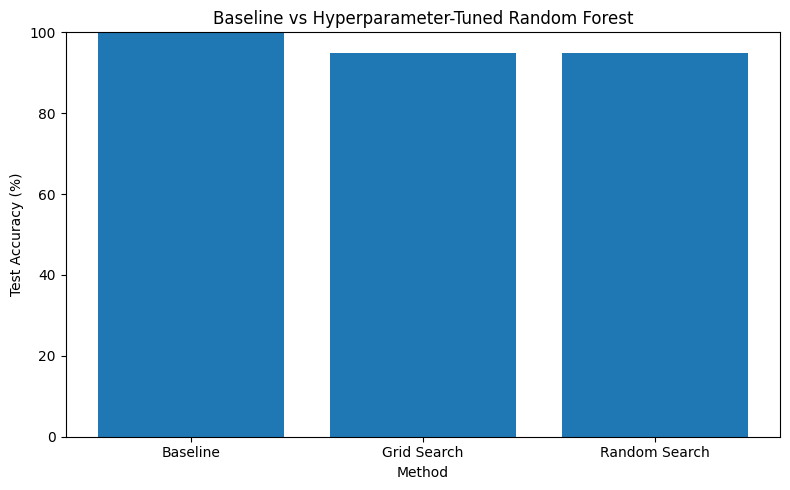

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Method"], comparison_df["Test Accuracy (%)"])
plt.ylabel("Test Accuracy (%)")
plt.xlabel("Method")
plt.title("Baseline vs Hyperparameter-Tuned Random Forest")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_result_table = grid_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

grid_result_table = grid_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(grid_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,50,None,2,1,0.975,0.030619,1
1,50,None,5,1,0.975,0.030619,1
2,200,None,5,1,0.975,0.030619,1
3,50,5,2,1,0.975,0.030619,1
4,200,5,2,1,0.975,0.030619,1
5,50,5,5,1,0.975,0.030619,1
6,200,5,5,1,0.975,0.030619,1
7,50,10,2,1,0.975,0.030619,1
8,50,10,5,1,0.975,0.030619,1
9,200,10,5,1,0.975,0.030619,1


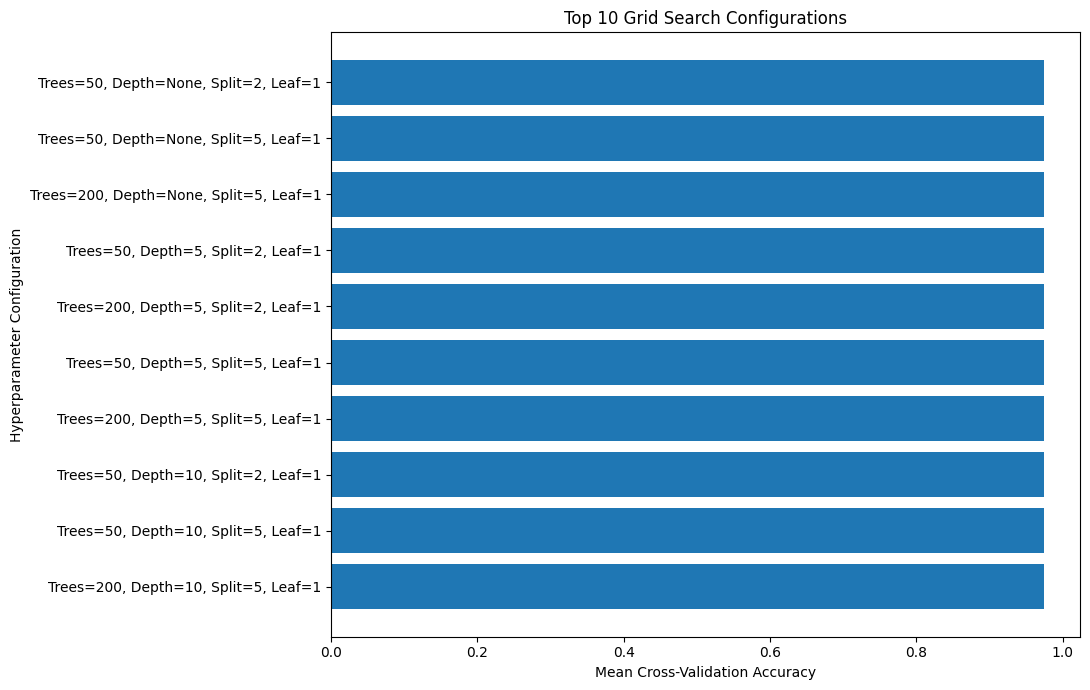

In [ ]:
top_grid = grid_result_table.head(10).copy()

top_grid["Configuration"] = (
    "Trees=" + top_grid["param_model__n_estimators"].astype(str)
    + ", Depth=" + top_grid["param_model__max_depth"].astype(str)
    + ", Split=" + top_grid["param_model__min_samples_split"].astype(str)
    + ", Leaf=" + top_grid["param_model__min_samples_leaf"].astype(str)
)

# Reverse only for display so the best configuration appears at the top.
top_grid_plot = top_grid.iloc[::-1]

plt.figure(figsize=(11, 7))
plt.barh(top_grid_plot["Configuration"], top_grid_plot["mean_test_score"])
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Hyperparameter Configuration")
plt.title("Top 10 Grid Search Configurations")
plt.tight_layout()
plt.show()

In [ ]:
random_results = pd.DataFrame(random_search.cv_results_)

random_result_table = random_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

random_result_table = random_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(random_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,mean_test_score,std_test_score,rank_test_score
0,200,15,4,2,None,1.000,0.000000,1
1,200,15,2,2,None,1.000,0.000000,1
2,100,10,4,2,None,1.000,0.000000,1
3,200,3,8,1,None,1.000,0.000000,1
4,300,5,4,2,None,1.000,0.000000,1
5,400,None,4,1,None,1.000,0.000000,1
6,400,5,2,1,None,1.000,0.000000,1
7,200,None,6,1,log2,0.975,0.030619,8
8,300,8,2,1,log2,0.975,0.030619,8
9,200,10,6,1,sqrt,0.975,0.030619,8


In [ ]:
grid_improvement_pp = (grid_accuracy - baseline_accuracy) * 100
random_improvement_pp = (random_accuracy - baseline_accuracy) * 100

print("Baseline test accuracy:      {:.2f}%".format(
    baseline_accuracy * 100
))

print("Grid Search test accuracy:   {:.2f}%".format(
    grid_accuracy * 100
))

print("Random Search test accuracy: {:.2f}%".format(
    random_accuracy * 100
))

print()

print("Grid Search impact:   {:+.2f} percentage points".format(
    grid_improvement_pp
))

print("Random Search impact: {:+.2f} percentage points".format(
    random_improvement_pp
))

if grid_improvement_pp > 0:
    print("Grid Search improved test accuracy.")
elif grid_improvement_pp < 0:
    print("Grid Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Grid Search produced no change in test accuracy.")

if random_improvement_pp > 0:
    print("Random Search improved test accuracy.")
elif random_improvement_pp < 0:
    print("Random Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Random Search produced no change in test accuracy.")

Baseline test accuracy:      100.00%
Grid Search test accuracy:   95.00%
Random Search test accuracy: 95.00%

Grid Search impact:   -5.00 percentage points
Random Search impact: -5.00 percentage points
Grid Search reduced test accuracy; the best CV configuration did not generalize better to this test split.
Random Search reduced test accuracy; the best CV configuration did not generalize better to this test split.


In [ ]:
model_candidates = {
    "Baseline": (baseline_accuracy, baseline_pipeline),
    "Grid Search": (grid_accuracy, grid_best_model),
    "Random Search": (random_accuracy, random_best_model)
}

best_method = max(
    model_candidates,
    key=lambda name: model_candidates[name][0]
)

final_accuracy, final_model = model_candidates[best_method]

FINAL_MODEL_PATH = "/content/best_skill_gap_random_forest.pkl"

joblib.dump(final_model, FINAL_MODEL_PATH)

print("Selected method:", best_method)
print("Selected test accuracy: {:.2f}%".format(
    final_accuracy * 100
))
print("Saved model:", FINAL_MODEL_PATH)

Selected method: Baseline
Selected test accuracy: 100.00%
Saved model: /content/best_skill_gap_random_forest.pkl


In [ ]:
loaded_model = joblib.load(FINAL_MODEL_PATH)


new_student_profile = pd.DataFrame({
    'Gender': ['Male'],
    'Semester': [7],
    'CGPA': [8.5],
    'Programming': [8],
    'DSA': [7],
    'DBMS': [6],
    'OS': [7],
    'CN': [5],
    'OOP': [8],
    'AI_ML': [7],
    'Communication': [9],
    'Aptitude': [8],
    'Teamwork': [9],
    'Problem_Solving': [8],
    'Internship': ['Yes'],
    'Certifications': [3],
    'Projects_Completed': [4],
    'Industry_Readiness': ['Ready']
})
prediction = loaded_model.predict(new_student_profile)[0]

print("Predicted Placement Status for a new student profile:", prediction)


Predicted Placement Status for a new student profile: Placed


In [ ]:
new_student_profile_for_skill_prediction = pd.DataFrame({
    'Gender': ['Male'],
    'Semester': [6],
    'CGPA': [7.0],
    'Programming': [6],
    'DSA': [5],
    'DBMS': [5],
    'OS': [6],
    'CN': [4],
    'OOP': [6],
    'AI_ML': [5],
    'Communication': [7],
    'Aptitude': [6],
    'Teamwork': [7],
    'Problem_Solving': [6],
    'Internship': ['No'],
    'Certifications': [1],
    'Projects_Completed': [2],
    'Industry_Readiness': ['Not Ready']
})
prediction = loaded_model.predict(new_student_profile_for_skill_prediction)[0]

print("Predicted Placement Status for a new student profile:", prediction)

Predicted Placement Status for a new student profile: Not Placed


In [ ]:
import mlflow

def log_hpo_run(
    run_name,
    tuning_method,
    model_object,
    test_accuracy,
    cv_accuracy=None,
    best_params=None
):
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param(
            "model",
            "RandomForestClassifier"
        )

        mlflow.log_param(
            "tuning_method",
            tuning_method
        )

        if best_params:
            mlflow.log_params({
                f"best_{k.replace('model__', '')}": v
                for k, v in best_params.items()
            })

        mlflow.log_metric(
            "test_accuracy",
            float(test_accuracy)
        )

        if cv_accuracy is not None:
            mlflow.log_metric(
                "best_cv_accuracy",
                float(cv_accuracy)
            )

        mlflow.sklearn.log_model(
            sk_model=model_object,
            name="model",
            serialization_format="cloudpickle"
        )


# Baseline
log_hpo_run(
    "RF_Baseline",
    "None",
    baseline_pipeline,
    baseline_accuracy
)


# Grid Search
log_hpo_run(
    "RF_GridSearch",
    "GridSearchCV",
    grid_best_model,
    grid_accuracy,
    grid_search.best_score_,
    grid_search.best_params_
)


log_hpo_run(
    "RF_RandomSearch",
    "RandomizedSearchCV",
    random_best_model,
    random_accuracy,
    random_search.best_score_,
    random_search.best_params_
)

print("MLflow runs logged successfully.")

2026/09/21 06:20:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 06:20:58 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 06:21:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 06:21:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 06:21:23 WARNING mlflow

MLflow runs logged successfully.


In [ ]:
import mlflow
import pandas as pd
experiments = mlflow.search_experiments()

for exp in experiments:
    print("Experiment ID:", exp.experiment_id)
    print("Experiment Name:", exp.name)
    print()

Experiment ID: 0
Experiment Name: Default



In [ ]:
import mlflow

runs = mlflow.search_runs(
    experiment_ids=["0"]
)

print("Number of runs:", len(runs))

columns = [
    "tags.mlflow.runName",
    "params.tuning_method",
    "metrics.best_cv_accuracy",
    "metrics.test_accuracy"
]

available_columns = [
    c for c in columns
    if c in runs.columns
]

display(
    runs[available_columns].sort_values(
        "metrics.test_accuracy",
        ascending=False
    )
)

Number of runs: 3


,tags.mlflow.runName,params.tuning_method,metrics.best_cv_accuracy,metrics.test_accuracy
2,RF_Baseline,None,NaN,1.00
0,RF_RandomSearch,RandomizedSearchCV,1.000,0.95
1,RF_GridSearch,GridSearchCV,0.975,0.95


In [ ]:
mlflow.set_experiment("Skill_Gap_Random_Forest")

2026/09/21 06:22:10 INFO mlflow.tracking.fluent: Experiment with name 'Skill_Gap_Random_Forest' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1789971730478, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789971730478, lifecycle_stage='active', name='Skill_Gap_Random_Forest', tags={}, trace_location=None, workspace='default'>

In [ ]:
experiment = mlflow.get_experiment_by_name(
    "Skill_Gap_Random_Forest"
)

print("Experiment ID:", experiment.experiment_id)
print("Experiment Name:", experiment.name)

Experiment ID: 1
Experiment Name: Skill_Gap_Random_Forest
